# Evaluation Report for the paper "_dlinear_: Enhancing SMT Solvers with Floating-Point Exact LP Solvers"

---

## 1. Executive Summary

This report presents a comprehensive comparison between the baseline [cvc5](https://github.com/cvc5/cvc5) SMT solver, the existing implementation using [GLPK](https://www.gnu.org/software/glpk/) as an external floating-point LP solver, and our proposed approach, _dlinear_, which uses floating-point exact LP solvers, specifically [SoPlex](https://github.com/scipopt/soplex) and [qsoptex](https://github.com/TendTo/qsopt-ex).
Additionally, we compare the results against the state-of-the-art SMT solver [Z3](https://github.com/Z3Prover/z3) and [yices](https://github.com/SRI-CSL/yices) to contextualize the performance of our approach in the broader landscape of SMT solvers.

The evaluation demonstrates that our integration provides significant performance improvements, particularly for instances requiring intensive linear arithmetic reasoning.

For more details on the contributions, please refer to the paper.

---

In [1]:
from IPython.display import Markdown as md
import pandas as pd
from functools import reduce
from utils import (
    compare_unique_solved_instances,
    build_markdown_comparison_matrix,
    plot_performance_profiles,
    sanitize,
    difficulty_analysis,
    print_stats,
    SolverResult,
    external_solver_impact,
)
from itertools import product
import os

DROP_UNSOLVED = False
SOLVERS = ("soplex", "qsoptex")
ITERATIONS = (100, 200,  300)
MODES = ("", "_strict",)

def get_tot_results_compare(result: SolverResult, iterations_filter: list[tuple[int, pd.DataFrame]]) -> int:
    header = ""
    middle = ""
    row = ""
    for iterations, instances in iterations_filter:
        results = result.dataframe[result.dataframe.index.isin(instances.index)]
        results = results[results[result.result_key].isin(["sat", "unsat"])]
        not_solved = len(instances) - len(results)
        header += f"| $n={iterations}$ solved | $n={iterations}$ unsolved "
        middle += f"| --- | --- "
        row += f"| {len(results)}/ {len(instances)} ({(len(results) / len(instances) * 100):.1f}%) | {not_solved}/ {len(instances)} ({(not_solved / len(instances) * 100):.1f}%) "
    return f"""
#### {result.solver_name} results for all pivots

| Solver               {header} |
| -------------------- {middle} |
| {result.solver_name} {row} |
"""

def difficulty_analysis_by_group(group: pd.DataFrame, iterations: int, group_name: str = "QF_LRA"):
    if iterations == 100:
        instances_filter = instances_100
        return md(difficulty_analysis(
            solvers_analysis=[
                others_results.get("yices", SolverResult.empty()).apply_filter(lambda df: in_instances(df, group, instances_filter)),
                others_results.get("z3", SolverResult.empty()).apply_filter(lambda df: in_instances(df, group, instances_filter)),
                others_results.get("cvc5", SolverResult.empty()).apply_filter(lambda df: in_instances(df, group, instances_filter)),
                others_results.get("glpk_i100", SolverResult.empty()).apply_filter(lambda df: in_instances(df, group, instances_filter)),
                results.get("soplex_i100", SolverResult.empty()).apply_filter(lambda df: in_instances(df, group, instances_filter)),
                results.get("soplex_i100_strict", SolverResult.empty()).apply_filter(lambda df: in_instances(df, group, instances_filter)),
                results.get("qsoptex_i100", SolverResult.empty()).apply_filter(lambda df: in_instances(df, group, instances_filter)),
                results.get("qsoptex_i100_strict", SolverResult.empty()).apply_filter(lambda df: in_instances(df, group, instances_filter)),
             ],
            total_count=len(pd.merge(group, instances_filter, on="file", how="inner")),
            group_name=f"{group_name} with $n = 100$ pivots threshold"
        ))
    elif iterations == 200:
        instances_filter = instances_200
        return md(difficulty_analysis(
            solvers_analysis=[
                others_results.get("yices", SolverResult.empty()).apply_filter(lambda df: in_instances(df, group, instances_filter)),
                others_results.get("z3", SolverResult.empty()).apply_filter(lambda df: in_instances(df, group, instances_filter)),
                others_results.get("cvc5", SolverResult.empty()).apply_filter(lambda df: in_instances(df, group, instances_filter)),
                others_results.get("glpk_i200", SolverResult.empty()).apply_filter(lambda df: in_instances(df, group, instances_filter)),
                results.get("soplex_i200", SolverResult.empty()).apply_filter(lambda df: in_instances(df, group, instances_filter)),
                results.get("soplex_i200_strict", SolverResult.empty()).apply_filter(lambda df: in_instances(df, group, instances_filter)),
                results.get("qsoptex_i200", SolverResult.empty()).apply_filter(lambda df: in_instances(df, group, instances_filter)),
                results.get("qsoptex_i200_strict", SolverResult.empty()).apply_filter(lambda df: in_instances(df, group, instances_filter)),
             ],
            total_count=len(pd.merge(group, instances_filter, on="file", how="inner")),
            group_name=f"{group_name} with $n = 200$ pivots threshold"
        ))
    elif iterations == 300:
        instances_filter = instances_300
        return md(difficulty_analysis(
            solvers_analysis=[
                others_results.get("yices", SolverResult.empty()).apply_filter(lambda df: in_instances(df, group, instances_filter)),
                others_results.get("z3", SolverResult.empty()).apply_filter(lambda df: in_instances(df, group, instances_filter)),
                others_results.get("cvc5", SolverResult.empty()).apply_filter(lambda df: in_instances(df, group, instances_filter)),
                others_results.get("glpk_i300", SolverResult.empty()).apply_filter(lambda df: in_instances(df, group, instances_filter)),
                results.get("soplex_i300", SolverResult.empty()).apply_filter(lambda df: in_instances(df, group, instances_filter)),
                results.get("soplex_i300_strict", SolverResult.empty()).apply_filter(lambda df: in_instances(df, group, instances_filter)),
                results.get("qsoptex_i300", SolverResult.empty()).apply_filter(lambda df: in_instances(df, group, instances_filter)),
                results.get("qsoptex_i300_strict", SolverResult.empty()).apply_filter(lambda df: in_instances(df, group, instances_filter)),
             ],
            total_count=len(pd.merge(group, instances_filter, on="file", how="inner")),
            group_name=f"{group_name} with $n = 300$ pivots threshold"
        ))

# Load the data
all_instances = pd.read_csv("instances/all_instances.csv").set_index("file")
instances_100 = pd.read_csv("instances/100_instances.csv").set_index("file")
instances_200 = pd.read_csv("instances/200_instances.csv").set_index("file")
instances_300 = pd.read_csv("instances/300_instances.csv").set_index("file")
miplib = pd.read_csv("instances/miplib.csv").set_index("file")
latendresse = pd.read_csv("instances/latendresse.csv").set_index("file")
dtp_scheduling = pd.read_csv("instances/dtp-scheduling.csv").set_index("file")

instances_dict = {
    100: instances_100,
    200: instances_200,
    300: instances_300,
}

def in_n(df: pd.DataFrame, n: int) -> pd.DataFrame:
    return df[df.index.isin(instances_dict[n].index)]

def in_instances(df: pd.DataFrame, *instances: pd.DataFrame) -> pd.DataFrame:
    if len(instances) == 0:
        return df
    if len(instances) == 1:
        return df[df.index.isin(instances[0].index)]
    return df[df.index.isin(pd.merge(*instances, how="inner", left_index=True, right_index=True).index)]

results: dict[str, SolverResult] = {}
for solver, iteration, m in product(SOLVERS, ITERATIONS, MODES):
    key = f"{solver}_i{iteration}{m}"
    file = f"results/{key}.csv"
    solver_id = solver[0].upper()
    if os.path.exists(file):
        df = pd.read_csv(file).set_index("file")
        df = df[df["theory::arith::z::arith::relax::calls"].astype(int) > 0]
        if DROP_UNSOLVED:
            df = df[df[f"result{solver_id}"].isin(["sat", "unsat"])]
        if m == "_strict":
            mode_str = "t"
        elif m == "_delta1e-08":
            mode_str = r"\delta"
        else:
            mode_str = r"\varepsilon"
        results[key] = SolverResult(solver_name=fr"$ \textbf{{d}}_{{{solver[:2].lower()},{iteration}}}^{mode_str} $", dataframe=df, solver_id=solver_id, iterations=iteration)

for key in results:
    results[key] = results[key].replace_df(sanitize(results[key].dataframe))

others = ("glpk_i100", "glpk_i200", "glpk_i300", "yices", "z3", "cvc5", )
others_results: dict[str, SolverResult] = {}
for others in others:
    if os.path.exists(f"results/{others}.csv"):
        df = pd.read_csv(f"results/{others}.csv").set_index("file")
        if DROP_UNSOLVED:
            df = df[df[f"result{others[0].upper()}"].isin(["sat", "unsat"])]
        iterations = f"_{{{others.split('_')[-1][1:]}}}" if "glpk" in others else ""
        df = df[df["theory::arith::z::arith::relax::calls"].astype(int) > 0] if "glpk" in others else df
        others_results[others] = SolverResult(solver_name=fr"$ \textbf{{{others[0].lower()}}}{iterations} $", dataframe=df, solver_id=others[0].upper(), iterations=int(iterations[2:-1]) if iterations else -1)

## 2. Overall Benchmark Performance

### 2.1 Problems Solved

This section summarizes the total number of instances solved by each approach across the entire QF_LRA benchmark set.
We use the [SMT-LIB](https://smt-lib.org/benchmarks.shtml) benchmarks for evaluation, restricting ourselves to the [QF_LRA](https://smt-lib.org/logics-all.shtml#QF_LRA) logic from the [SMT-LIB release 2025 of non-incremental benchmarks](https://zenodo.org/records/16740866).
The complete benchmark set consists of 1,753 instances. However, our evaluation uses only a subset, namely those instances that invoke the external LP solver at least once.

### 2.2 Experimental Setup

- **Timeout**: 6 hours per instance
- **Memory limit**: 4 GB
- **Hardware**: Comet HPC cluster (Newcastle University), using a single core of an AMD EPYC 9745 processor @ 2.4 GHz

### 2.3 Hardware Details

| OS            | CPU           | Architecture | Frequency | Turbo Frequency | Cores | Memory | L1      | L2        | L3     | Time Limit |
| ------------- | ------------- | ------------ | --------- | --------------- | ----- | ------ | ------- | --------- | ------ | ---------- |
| RHEL 11.4.1-4 | AMD EPYC 9745 | x86_64       | 2.4 GHz   | 3.7 GHz         | 1     | 4 GB   | 6144 KB | 131072 KB | 256 MB | 6 hours    |

In [2]:
header = "| Total number of instances "
middle = "|:---:"
key = f"| {len(all_instances)} "
for iterations in ITERATIONS:
    header += f"| Instances with at least one external LP solver call with $n={iterations}$ iterations threshold "
    middle += "|:---:"
    key += f"| {len(in_n(all_instances, iterations))} "
header += "|"
middle += "|"
key += "|"

md(f"""### Instances
   
Starting from the original {len(all_instances)} instances, the table below shows how many instances required at least a call to the external LP solver for the given iteration threshold.
   
{header}
{middle}
{key}
   """)

### Instances

Starting from the original 1753 instances, the table below shows how many instances required at least a call to the external LP solver for the given iteration threshold.

| Total number of instances | Instances with at least one external LP solver call with $n=100$ iterations threshold | Instances with at least one external LP solver call with $n=200$ iterations threshold | Instances with at least one external LP solver call with $n=300$ iterations threshold |
|:---:|:---:|:---:|:---:|
| 1753 | 319 | 177 | 125 |
   

### 2.4 Solver Notation

When abbreviating the solvers, we use the following conventions:

- $\textbf{c}$, $\textbf{y}$, and $\textbf{z}$ for _cvc5_, _yices_, and _z3_, respectively
- $\textbf{g}_n$ for _glpk_, where $n \in \{100, 200, 300\}$ is the number of pivots before calling the external LP solver
- $\textbf{d}^m_{s,n}$ for _dlinear_, where:
  - $s \in \{\text{so}, \text{qs}\}$ indicates the external LP solver (_soplex_ or _qsoptex_)
  - $m \in \{\varepsilon, t\}$ indicates how strict inequalities are handled (epsilon or tight bounds)
  - $n$ is the pivot threshold as described above

In [3]:
md(
    fr"""### 2.5 Loading _dlinear_ results
   
In the following table, we summarize the loaded results for each solver configuration. 
Each row corresponds to a specific configuration of our _dlinear_ approach, with different pivot thresholds (100, 200, 300) and modes (epsilon, strict, delta). 
The "Loaded Instances" column indicates how many benchmark instances were successfully loaded for each configuration.
Higher pivot thresholds are expected to have less loaded instances, as we only consider those that performed at least one call to the external LP solver.

The _Mode_ column indicates how constraints with strict inequalities (i.e., $<, >$) are handled.
The possible modes are:
   
- $\varepsilon$: The default mode, which uses a small perturbation $\varepsilon$ on the right-hand side of the constraints to ensure strict inequalities are satisfied.
- $t$: A mode that adds and additional strict variable $t$ to constraint containing strict inequalities, and then tries to maximize $t$ to ensure that the constraints are satisfied with a positive margin.
   
Additional details can be found in _Sections 4.2_ of the paper.
   
| Solver | Mode |  Pivot Threshold | Available Instances | Solved Instances | Unsolved Instances |
|--------|-----------------|------|-------------------| -----------------|-------------------|
{"".join(f"| {res.solver_name} | {res.mode}  | {res.iterations} | {len(in_n(all_instances, res.iterations))} | {len(res.dataframe[res.dataframe['result'].isin(['sat', 'unsat'])])} ({len(res.dataframe[res.dataframe['result'].isin(['sat', 'unsat'])]) / len(in_n(all_instances, res.iterations)) * 100:.1f}%) | {len(in_n(all_instances, res.iterations)) - len(res.dataframe[res.dataframe['result'].isin(['sat', 'unsat'])])} ({(len(in_n(all_instances, res.iterations)) - len(res.dataframe[res.dataframe['result'].isin(['sat', 'unsat'])])) / len(in_n(all_instances, res.iterations)) * 100:.1f}%) |\n" for res in results.values())}
"""
)

### 2.5 Loading _dlinear_ results

In the following table, we summarize the loaded results for each solver configuration. 
Each row corresponds to a specific configuration of our _dlinear_ approach, with different pivot thresholds (100, 200, 300) and modes (epsilon, strict, delta). 
The "Loaded Instances" column indicates how many benchmark instances were successfully loaded for each configuration.
Higher pivot thresholds are expected to have less loaded instances, as we only consider those that performed at least one call to the external LP solver.

The _Mode_ column indicates how constraints with strict inequalities (i.e., $<, >$) are handled.
The possible modes are:

- $\varepsilon$: The default mode, which uses a small perturbation $\varepsilon$ on the right-hand side of the constraints to ensure strict inequalities are satisfied.
- $t$: A mode that adds and additional strict variable $t$ to constraint containing strict inequalities, and then tries to maximize $t$ to ensure that the constraints are satisfied with a positive margin.

Additional details can be found in _Sections 4.2_ of the paper.

| Solver | Mode |  Pivot Threshold | Available Instances | Solved Instances | Unsolved Instances |
|--------|-----------------|------|-------------------| -----------------|-------------------|
| $ \textbf{d}_{so,100}^\varepsilon $ | $\varepsilon$  | 100 | 319 | 287 (90.0%) | 32 (10.0%) |
| $ \textbf{d}_{so,100}^t $ | $t$  | 100 | 319 | 254 (79.6%) | 65 (20.4%) |
| $ \textbf{d}_{so,200}^\varepsilon $ | $\varepsilon$  | 200 | 177 | 153 (86.4%) | 24 (13.6%) |
| $ \textbf{d}_{so,200}^t $ | $t$  | 200 | 177 | 151 (85.3%) | 26 (14.7%) |
| $ \textbf{d}_{so,300}^\varepsilon $ | $\varepsilon$  | 300 | 125 | 107 (85.6%) | 18 (14.4%) |
| $ \textbf{d}_{so,300}^t $ | $t$  | 300 | 125 | 100 (80.0%) | 25 (20.0%) |
| $ \textbf{d}_{qs,100}^\varepsilon $ | $\varepsilon$  | 100 | 319 | 281 (88.1%) | 38 (11.9%) |
| $ \textbf{d}_{qs,100}^t $ | $t$  | 100 | 319 | 287 (90.0%) | 32 (10.0%) |
| $ \textbf{d}_{qs,200}^\varepsilon $ | $\varepsilon$  | 200 | 177 | 150 (84.7%) | 27 (15.3%) |
| $ \textbf{d}_{qs,200}^t $ | $t$  | 200 | 177 | 155 (87.6%) | 22 (12.4%) |
| $ \textbf{d}_{qs,300}^\varepsilon $ | $\varepsilon$  | 300 | 125 | 99 (79.2%) | 26 (20.8%) |
| $ \textbf{d}_{qs,300}^t $ | $t$  | 300 | 125 | 107 (85.6%) | 18 (14.4%) |



### 2.6 Comparison between external LP solvers: GLPK, SoPlex and qsoptex

We compare the performance of these three external LP solvers when integrated into cvc5, across different pivot thresholds and operational modes.

In [4]:
md(print_stats(
    soplex_configs=(list(results.values()) + [val for val in others_results.values() if val.solver_id == "G"]),
))

### Summary statistics for each configuration with an external LP solver
| Config       | Registered results | Solved | Unknown | Tot Time | Med Time | Med LP Time | Med LP Setup Time | Adjustment calls | Med Adjustment calls | $>1$ Adj. Pivot |
| ------------ | -------------- | ------ | ------- | ---------- | --------- | ---- | ---- | ---------------- | ---------------------- | ----------------- |
| $ \textbf{d}_{so,100}^\varepsilon $ | 305 | 287 | 18 | 789132 | 251.31           | 1.08            | 0.34            | 4127997 | 944.00          | 56 |
| $ \textbf{d}_{so,100}^t $ | 255 | 254 | 1 | 209243 | 152.08           | 0.24            | 0.20            | 3864 | 7.00            | 26 |
| $ \textbf{d}_{so,200}^\varepsilon $ | 168 | 153 | 15 | 589429 | 549.74           | 2.31            | 0.66            | 2685263 | 2455.00         | 35 |
| $ \textbf{d}_{so,200}^t $ | 160 | 151 | 9 | 424699 | 262.30           | 0.41            | 0.45            | 325836 | 223.00          | 9 |
| $ \textbf{d}_{so,300}^\varepsilon $ | 117 | 107 | 10 | 410879 | 247.12           | 1.62            | 0.41            | 247412 | 481.00          | 34 |
| $ \textbf{d}_{so,300}^t $ | 109 | 100 | 9 | 357193 | 139.00           | 0.84            | 0.68            | 11926 | 228.00          | 8 |
| $ \textbf{d}_{qs,100}^\varepsilon $ | 295 | 281 | 14 | 646182 | 211.94           | 3.52            | 0.74            | 4187 | 76.00           | 29 |
| $ \textbf{d}_{qs,100}^t $ | 303 | 287 | 16 | 717837 | 219.37           | 0.62            | 1.40            | 760107 | 37.00           | 25 |
| $ \textbf{d}_{qs,200}^\varepsilon $ | 159 | 150 | 9 | 421687 | 282.19           | 4.43            | 0.96            | 291 | 1.00            | 9 |
| $ \textbf{d}_{qs,200}^t $ | 167 | 155 | 12 | 494954 | 351.37           | 1.07            | 1.23            | 4485 | 28.00           | 11 |
| $ \textbf{d}_{qs,300}^\varepsilon $ | 110 | 99 | 11 | 359802 | 221.77           | 7.17            | 1.28            | 345 | 1.00            | 7 |
| $ \textbf{d}_{qs,300}^t $ | 117 | 107 | 10 | 423805 | 232.02           | 1.57            | 1.60            | 4588 | 61.00           | 6 |
| $ \textbf{g}_{100} $ | 312 | 199 | 113 | 2631490 | 948.99           | 1.35            | 2.65            | 493542310 | 209103.00       | 268 |
| $ \textbf{g}_{200} $ | 171 | 112 | 59 | 1421538 | 1463.37          | 0.34            | 0.34            | 289651830 | 16919.00        | 149 |
| $ \textbf{g}_{300} $ | 121 | 82 | 39 | 953121 | 560.04           | 0.30            | 0.18            | 123750155 | 2479.00         | 102 |
    

_**Table 1** from the paper_

### 2.7 External Solver Impact

Calls to the external simplex solver can significantly affect the overall performance of the SMT solver, particularly when precision boosting and iterative refinement techniques are costly, a common scenario for numerically challenging instances. Here, we analyze the impact of:

- **Precision boosting**: The number $p_n$ of calls that required $n$ bits of precision
- **Iterative refinements**: The number $r_i$ of calls that required $i$ refinement iterations

This analysis helps quantify the overhead introduced by exact arithmetic techniques.

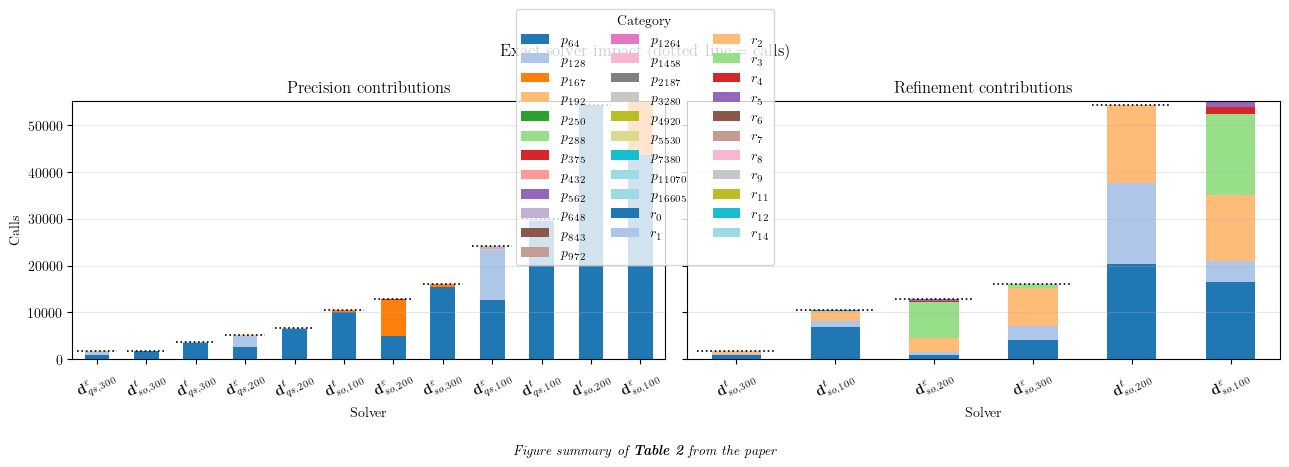

## External solver impact

Analysis on the impact of the external simplex solver on the overall performance of the SMT solver, based on the number of calls to the external simplex and the techniques used to obtain the exact solution (precision boosting and iterative refinements).
    
| Solver | Calls | $p_{64}$ | $p_{128}$ | $p_{167}$ | $p_{192}$ | $p_{250}$ | $p_{288}$ | $p_{375}$ | $p_{432}$ | $p_{562}$ | $p_{648}$ | $p_{843}$ | $p_{972}$ | $p_{1264}$ | $p_{1458}$ | $p_{2187}$ | $p_{3280}$ | $p_{4920}$ | $p_{5530}$ | $p_{7380}$ | $p_{11070}$ | $p_{16605}$ | $r_{0}$ | $r_{1}$ | $r_{2}$ | $r_{3}$ | $r_{4}$ | $r_{5}$ | $r_{6}$ | $r_{7}$ | $r_{8}$ | $r_{9}$ | $r_{11}$ | $r_{12}$ | $r_{14}$ |
| ------ | ----- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| $ \textbf{d}_{so,100}^\varepsilon $ | 55234 | 43747 | | 11392 | | 42 | | 14 | | 5 | | 6 | | 28 | | | | | | | | | 16569 | 4521 | 13962 | 17370 | 1517 | 1104 | 71 | 66 | 51 | 2 | 1 | | |
| $ \textbf{d}_{so,100}^t $ | 10467 | 10105 | | 357 | | 5 | | | | | | | | | | | | | | | | | 6800 | 1407 | 1980 | 113 | 89 | 61 | 2 | 9 | 4 | 1 | | 1 | |
| $ \textbf{d}_{so,200}^\varepsilon $ | 12835 | 4996 | | 7735 | | 32 | | 23 | | 14 | | 8 | | 27 | | | | | | | | | 893 | 753 | 2904 | 7773 | 181 | 290 | 26 | 6 | 5 | | | | 4 |
| $ \textbf{d}_{so,200}^t $ | 54240 | 54229 | | 11 | | | | | | | | | | | | | | | | | | | 20440 | 17235 | 16557 | 4 | 3 | 1 | | | | | | | |
| $ \textbf{d}_{so,300}^\varepsilon $ | 16054 | 15495 | | 484 | | 37 | | 8 | | 8 | | 5 | | 17 | | | | | | | | | 4080 | 3076 | 8075 | 755 | 43 | 20 | 3 | 2 | 0 | | | | |
| $ \textbf{d}_{so,300}^t $ | 1787 | 1781 | | 6 | | | | | | | | | | | | | | | | | | | 981 | 179 | 624 | 1 | 1 | 1 | | | | | | | |
| $ \textbf{d}_{qs,100}^\varepsilon $ | 24104 | 12650 | 10736 | | 151 | | 88 | | 35 | | 361 | | 6 | | 2 | 1 | 1 | 2 | 1 | 2 | 1 | 67 | | | | | | | | | | | | | |
| $ \textbf{d}_{qs,100}^t $ | 29877 | 29635 | 238 | | 2 | | 2 | | | | | | | | | | | | | | | | | | | | | | | | | | | | |
| $ \textbf{d}_{qs,200}^\varepsilon $ | 5191 | 2565 | 2508 | | 33 | | 23 | | 10 | | 47 | | 2 | | | | | | | | | 3 | | | | | | | | | | | | | |
| $ \textbf{d}_{qs,200}^t $ | 6605 | 6377 | 228 | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | |
| $ \textbf{d}_{qs,300}^\varepsilon $ | 1716 | 912 | 746 | | 13 | | 8 | | 5 | | 28 | | 1 | | | | | | | | | 3 | | | | | | | | | | | | | |
| $ \textbf{d}_{qs,300}^t $ | 3778 | 3554 | 224 | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | |


In [5]:
md(external_solver_impact(
    solvers_analysis=results.values(),
    fig_caption=r"$\textit{Figure summary of \textbf{Table 2} from the paper}$"
))

_**Table 2** from the paper_

## 3. Difficulty and Performance Analysis

### 3.1 Difficulty Analysis

We analyze the distribution of solving times across the benchmark instances, dividing them into different buckets based on the time taken to solve each instance.

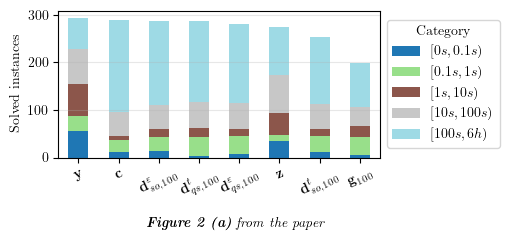

## Difficulty analysis on instances with $n = 100$ pivots threshold

All problems are divided into buckets depending on the time taken by the solver to solve them.

| Solver | Modes  | Pivots | Very Fast (<0.1s) | Fast (0.1-1s) | Medium (1-10s) | Hard (10-100s) | Very Hard (>100s) | Total |
| ------ | ------ | ------ | ----------------- | ------------- | -------------- | -------------- | ----------------- | ----- |
| $ \textbf{y} $ | $\varepsilon$ | 0 | 56 (19.0%) | 32 (10.9%) | 66 (22.4%) | 74 (25.2%) | 66 (22.4%) | 294 / 319 (92.2%)
| $ \textbf{z} $ | $\varepsilon$ | 0 | 34 (12.4%) | 14 (5.1%) | 45 (16.4%) | 81 (29.5%) | 101 (36.7%) | 275 / 319 (86.2%)
| $ \textbf{c} $ | $\varepsilon$ | 0 | 12 (4.2%) | 24 (8.3%) | 10 (3.5%) | 50 (17.3%) | 193 (66.8%) | 289 / 319 (90.6%)
| $ \textbf{g}_{100} $ | $\varepsilon$ | 100 | 6 (3.0%) | 38 (19.1%) | 22 (11.1%) | 41 (20.6%) | 92 (46.2%) | 199 / 319 (62.4%)
| $ \textbf{d}_{so,100}^\varepsilon $ | $\varepsilon$ | 100 | 14 (4.9%) | 30 (10.5%) | 16 (5.6%) | 50 (17.4%) | 177 (61.7%) | 287 / 319 (90.0%)
| $ \textbf{d}_{so,100}^t $ | $t$ | 100 | 11 (4.3%) | 34 (13.4%) | 15 (5.9%) | 52 (20.5%) | 142 (55.9%) | 254 / 319 (79.6%)
| $ \textbf{d}_{qs,100}^\varepsilon $ | $\varepsilon$ | 100 | 8 (2.8%) | 37 (13.2%) | 16 (5.7%) | 54 (19.2%) | 166 (59.1%) | 281 / 319 (88.1%)
| $ \textbf{d}_{qs,100}^t $ | $t$ | 100 | 4 (1.4%) | 40 (13.9%) | 18 (6.3%) | 54 (18.8%) | 171 (59.6%) | 287 / 319 (90.0%)


In [6]:
md(difficulty_analysis(
    solvers_analysis=[
        others_results.get("yices", SolverResult.empty()).apply_filter(lambda df: in_n(df, 100)),
        others_results.get("z3", SolverResult.empty()).apply_filter(lambda df: in_n(df, 100)),
        others_results.get("cvc5", SolverResult.empty()).apply_filter(lambda df: in_n(df, 100)),
        others_results.get("glpk_i100", SolverResult.empty()),
        results.get("soplex_i100", SolverResult.empty()),
        results.get("soplex_i100_strict", SolverResult.empty()),
        # results.get("soplex_i100_delta1e-08"),
        results.get("qsoptex_i100", SolverResult.empty()),
        results.get("qsoptex_i100_strict", SolverResult.empty()),
        # results.get("qsoptex_i100_delta1e-08"),
    ],
    total_count= len(instances_100),
    group_name="instances with $n = 100$ pivots threshold",
    fig_caption=r"$\textit{\textbf{Figure 2 (a)} from the paper}$"
))

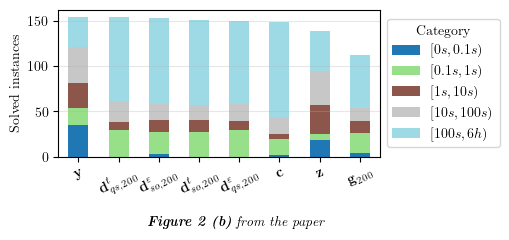

## Difficulty analysis on instances with $n = 200$ pivots threshold

All problems are divided into buckets depending on the time taken by the solver to solve them.

| Solver | Modes  | Pivots | Very Fast (<0.1s) | Fast (0.1-1s) | Medium (1-10s) | Hard (10-100s) | Very Hard (>100s) | Total |
| ------ | ------ | ------ | ----------------- | ------------- | -------------- | -------------- | ----------------- | ----- |
| $ \textbf{y} $ | $\varepsilon$ | 0 | 35 (22.6%) | 19 (12.3%) | 27 (17.4%) | 40 (25.8%) | 34 (21.9%) | 155 / 177 (87.6%)
| $ \textbf{z} $ | $\varepsilon$ | 0 | 18 (12.9%) | 7 (5.0%) | 32 (23.0%) | 38 (27.3%) | 44 (31.7%) | 139 / 177 (78.5%)
| $ \textbf{c} $ | $\varepsilon$ | 0 | 2 (1.3%) | 17 (11.4%) | 6 (4.0%) | 19 (12.8%) | 105 (70.5%) | 149 / 177 (84.2%)
| $ \textbf{g}_{200} $ | $\varepsilon$ | 200 | 4 (3.6%) | 22 (19.6%) | 13 (11.6%) | 15 (13.4%) | 58 (51.8%) | 112 / 177 (63.3%)
| $ \textbf{d}_{so,200}^\varepsilon $ | $\varepsilon$ | 200 | 3 (2.0%) | 24 (15.7%) | 14 (9.2%) | 17 (11.1%) | 95 (62.1%) | 153 / 177 (86.4%)
| $ \textbf{d}_{so,200}^t $ | $t$ | 200 | 0 | 27 (17.9%) | 14 (9.3%) | 16 (10.6%) | 94 (62.3%) | 151 / 177 (85.3%)
| $ \textbf{d}_{qs,200}^\varepsilon $ | $\varepsilon$ | 200 | 0 | 29 (19.3%) | 10 (6.7%) | 19 (12.7%) | 92 (61.3%) | 150 / 177 (84.7%)
| $ \textbf{d}_{qs,200}^t $ | $t$ | 200 | 0 | 29 (18.7%) | 9 (5.8%) | 24 (15.5%) | 93 (60.0%) | 155 / 177 (87.6%)


In [7]:
md(difficulty_analysis(
    solvers_analysis=[
        others_results.get("yices",SolverResult.empty()).apply_filter(lambda df: in_n(df, 200)),
        others_results.get("z3",SolverResult.empty()).apply_filter(lambda df: in_n(df, 200)),
        others_results.get("cvc5",SolverResult.empty()).apply_filter(lambda df: in_n(df, 200)),
        others_results.get("glpk_i200",SolverResult.empty()),
        results.get("soplex_i200",SolverResult.empty()),
        results.get("soplex_i200_strict",SolverResult.empty()),
        # results.get("soplex_i200_delta1e-08"),
        results.get("qsoptex_i200",SolverResult.empty()),
        results.get("qsoptex_i200_strict",SolverResult.empty()),
        # results.get("qsoptex_i200_delta1e-08"),
    ],
   total_count= len(instances_200),
   group_name="instances with $n = 200$ pivots threshold",
    fig_caption=r"$\textit{\textbf{Figure 2 (b)} from the paper}$"
))

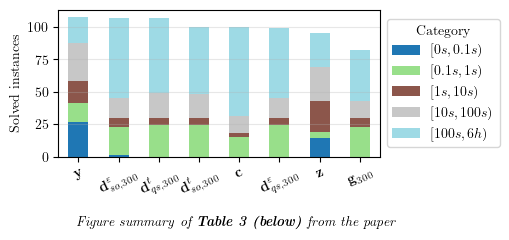

## Difficulty analysis on instances with $n = 300$ pivots threshold

All problems are divided into buckets depending on the time taken by the solver to solve them.

| Solver | Modes  | Pivots | Very Fast (<0.1s) | Fast (0.1-1s) | Medium (1-10s) | Hard (10-100s) | Very Hard (>100s) | Total |
| ------ | ------ | ------ | ----------------- | ------------- | -------------- | -------------- | ----------------- | ----- |
| $ \textbf{y} $ | $\varepsilon$ | 0 | 27 (25.0%) | 14 (13.0%) | 17 (15.7%) | 30 (27.8%) | 20 (18.5%) | 108 / 125 (86.4%)
| $ \textbf{z} $ | $\varepsilon$ | 0 | 14 (14.7%) | 5 (5.3%) | 24 (25.3%) | 26 (27.4%) | 26 (27.4%) | 95 / 125 (76.0%)
| $ \textbf{c} $ | $\varepsilon$ | 0 | 0 | 15 (15.0%) | 3 (3.0%) | 13 (13.0%) | 69 (69.0%) | 100 / 125 (80.0%)
| $ \textbf{g}_{300} $ | $\varepsilon$ | 300 | 0 | 23 (28.0%) | 7 (8.5%) | 13 (15.9%) | 39 (47.6%) | 82 / 125 (65.6%)
| $ \textbf{d}_{so,300}^\varepsilon $ | $\varepsilon$ | 300 | 1 (0.9%) | 22 (20.6%) | 7 (6.5%) | 15 (14.0%) | 62 (57.9%) | 107 / 125 (85.6%)
| $ \textbf{d}_{so,300}^t $ | $t$ | 300 | 0 | 24 (24.0%) | 6 (6.0%) | 18 (18.0%) | 52 (52.0%) | 100 / 125 (80.0%)
| $ \textbf{d}_{qs,300}^\varepsilon $ | $\varepsilon$ | 300 | 0 | 24 (24.2%) | 6 (6.1%) | 15 (15.2%) | 54 (54.5%) | 99 / 125 (79.2%)
| $ \textbf{d}_{qs,300}^t $ | $t$ | 300 | 0 | 24 (22.4%) | 6 (5.6%) | 19 (17.8%) | 58 (54.2%) | 107 / 125 (85.6%)


In [8]:
md(difficulty_analysis(
    solvers_analysis=[
        others_results.get("yices", SolverResult.empty()).apply_filter(lambda df: in_n(df, 300)),
        others_results.get("z3", SolverResult.empty()).apply_filter(lambda df: in_n(df, 300)),
        others_results.get("cvc5", SolverResult.empty()).apply_filter(lambda df: in_n(df, 300)),
        others_results.get("glpk_i300", SolverResult.empty()),
        results.get("soplex_i300", SolverResult.empty()),
        results.get("soplex_i300_strict", SolverResult.empty()),
        results.get("qsoptex_i300", SolverResult.empty()),
        results.get("qsoptex_i300_strict", SolverResult.empty()),
    ],
   total_count= len(instances_300),
   group_name="instances with $n = 300$ pivots threshold",
   fig_caption=r"$\textit{Figure summary of \textbf{Table 3 (below)} from the paper}$"
))

### 3.2 Performance Profiles 

Performance profiles are a powerful tool for comparing the performance of multiple solvers across a benchmark set.
They highlight the percentage of instance each solver can complete withing a certain time factor of the best solver for each instance, providing a clear visualization of relative performance.

In [9]:
def to_new_solver_id(solver_result: SolverResult):
    return f"{solver_result.solver_id}{solver_result.iterations}{'S' if '^t' in solver_result.solver_name.lower() else ''}{'D' if r'\delta' in solver_result.solver_name.lower() else ''}"

cvc5_variants_results = [
    SolverResult(
        dataframe=solver_result.dataframe.reset_index()[
            ["file", f"time{solver_result.solver_id}", f"result{solver_result.solver_id}", *(["options::pivots"] if "options::pivots" in solver_result.dataframe.columns else [])]
        ]
        .rename(
            columns={
                f"time{solver_result.solver_id}": f"time{to_new_solver_id(solver_result)}",
                f"result{solver_result.solver_id}": f"result{to_new_solver_id(solver_result)}",
            }
        )
        .set_index("file"),
        solver_name=solver_result.solver_name,
        solver_id=to_new_solver_id(solver_result),
        iterations=solver_result.iterations,
    )
    for solver_result in (results | others_results).values()
    if solver_result.solver_id in ["C", "S", "Q", "G"]
]

other_profile_results = [
    SolverResult(
        dataframe=solver_result.dataframe.reset_index()[
            ["file", f"time{solver_result.solver_id}", f"result{solver_result.solver_id}"]
        ]
        .rename(
            columns={
                f"time{solver_result.solver_id}": f"time{to_new_solver_id(solver_result)}",
                f"result{solver_result.solver_id}": f"result{to_new_solver_id(solver_result)}",
            }
        )
        .set_index("file"),
        solver_name=solver_result.solver_name,
        solver_id=to_new_solver_id(solver_result),
        iterations=solver_result.iterations,
    )
    for solver_result in others_results.values()
    if solver_result.solver_id in ["Y", "Z"]
]

# Get the set of instances where any of the SoPlex variants makes external simplex calls, and filter all profiles to only those instances
external_cvc5_variants_results: dict[int, list[SolverResult]] = {}
external_profile_results: dict[int, list[SolverResult]] = {}
for iteration in ITERATIONS:
        external_cvc5_variants_results[iteration] = [
            result.replace_df(in_n(result.dataframe.drop(columns=["options::pivots"], errors="ignore"), iteration))
            for result in cvc5_variants_results
            if not result.dataframe.empty and ("options::pivots" not in result.dataframe.columns or result.dataframe["options::pivots"].iloc[0] == iteration)
        ]
        external_profile_results[iteration] = external_cvc5_variants_results[iteration] + [
            result.replace_df(in_n(result.dataframe, iteration)) for result in other_profile_results
        ]

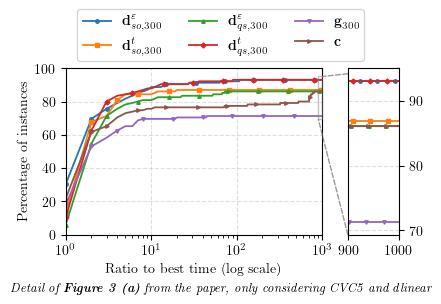

In [10]:
if 300 in external_cvc5_variants_results and len(external_cvc5_variants_results[300]) > 1:
    ax, fig = plot_performance_profiles(
        *external_cvc5_variants_results[300],
        accepted_results=["sat", "unsat"],
        result_cols="result",
        metric_cols="time",
        max_tau=1000,
        num_points=1000,
        fig_caption=r"$\textit{Detail of \textbf{Figure 3 (a)} from the paper, only considering CVC5 and dlinear}$"
    )

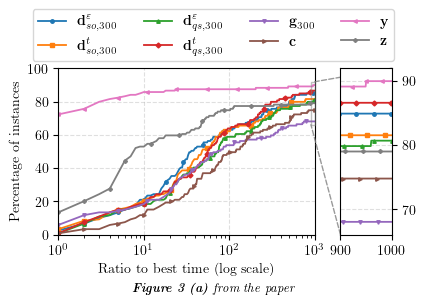

In [11]:
if 300 in external_profile_results and len(external_cvc5_variants_results[300]) > 1:
    ax, fig = plot_performance_profiles(
        *external_profile_results[300],
        accepted_results=["sat", "unsat"],
        result_cols="result",
        metric_cols="time",
        max_tau=1000,
        num_points=1000,
        fig_caption=r"$\textit{\textbf{Figure 3 (a)} from the paper}$"
    )

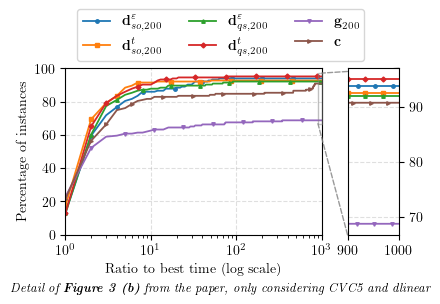

In [12]:
if 200 in external_cvc5_variants_results and len(external_cvc5_variants_results[200]) > 1:
    ax, fig = plot_performance_profiles(
        *external_cvc5_variants_results[200],
        accepted_results=["sat", "unsat"],
        result_cols="result",
        metric_cols="time",
        max_tau=1000,
        fig_caption=r"$\textit{Detail of \textbf{Figure 3 (b)} from the paper, only considering CVC5 and dlinear}$"
    )

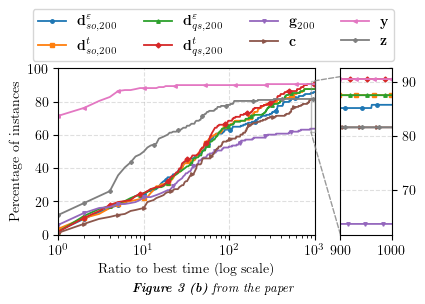

In [13]:
if 200 in external_profile_results and len(external_cvc5_variants_results[200]) > 1:
    ax, fig = plot_performance_profiles(
        *external_profile_results[200],
        accepted_results=["sat", "unsat"],
        result_cols="result",
        metric_cols="time",
        max_tau=1000,
        fig_caption=r"$\textit{\textbf{Figure 3 (b)} from the paper}$"
    )

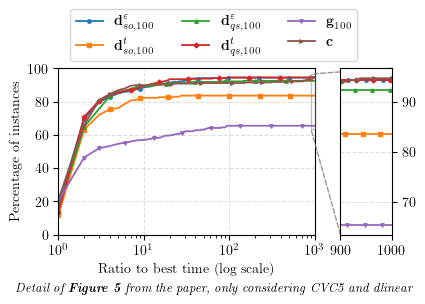

In [14]:
if 100 in external_cvc5_variants_results and len(external_cvc5_variants_results[100]) > 1:
    ax, fig = plot_performance_profiles(
        *external_cvc5_variants_results[100],
        accepted_results=["sat", "unsat"],
        result_cols="result",
        metric_cols="time",
        max_tau=1000,
        fig_caption=r"$\textit{Detail of \textbf{Figure 5} from the paper, only considering CVC5 and dlinear}$"
    )

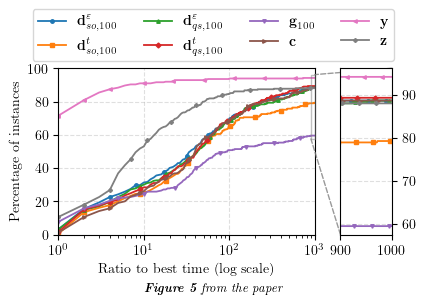

In [15]:
if 100 in external_profile_results and len(external_cvc5_variants_results[100]) > 1:
    ax, fig = plot_performance_profiles(
        *external_profile_results[100],
        accepted_results=["sat", "unsat"],
        result_cols="result",
        metric_cols="time",
        max_tau=1000,
        fig_caption=r"$\textit{\textbf{Figure 5} from the paper}$"
    )

### 3.3 All results

We present the complete results for all solvers across all instances in the benchmark set, providing a comprehensive view of the performance landscape.
These are the same tables that are included in the paper as **Table 8**, **Table 9**, and **Table 10**.

In [16]:
all_results = []
column_map = {
    "timeY-1": r"yices",
    "timeZ-1": r"z3",
    "timeC-1": r"cvc5",
    "timeG100": r"cvc5+glpk (100)",
    "timeG200": r"cvc5+glpk (200)",
    "timeG300": r"cvc5+glpk (300)",
    "timeS100": r"dlinear+soplex (e) (100)",
    "timeS100S": r"dlinear+soplex (t) (100)",
    "timeS200": r"dlinear+soplex (e) (200)",
    "timeS200S": r"dlinear+soplex (t) (200)",
    "timeS300": r"dlinear+soplex (e) (300)",
    "timeS300S": r"dlinear+soplex (t) (300)",
    "timeQ100": r"dlinear+qsoptex (e) (100)",
    "timeQ100S": r"dlinear+qsoptex (t) (100)",
    "timeQ200": r"dlinear+qsoptex (e) (200)",
    "timeQ200S": r"dlinear+qsoptex (t) (200)",
    "timeQ300": r"dlinear+qsoptex (e) (300)",
    "timeQ300S": r"dlinear+qsoptex (t) (300)",
}
for iteration in ITERATIONS:
    df_all = reduce(
        lambda left, right: pd.merge(left, right, left_index=True, right_index=True, how="outer"), (in_n(result.dataframe, iteration) for result in external_profile_results[iteration])
    )
    df_all_column_map = {col: name for col, name in column_map.items() if col in df_all.columns}
    df_all["problem_index"] = df_all.index
    df_all["problem_index"] = df_all["problem_index"].apply(lambda x: instances_dict[100].index.get_loc(x))
    df_all["Problem"] = df_all.index
    df_all["Problem"] = df_all["Problem"].apply(lambda x: f"({instances_dict[100].index.get_loc(x)})")
    all_results.append(df_all.sort_values("problem_index")[list(df_all_column_map.keys())].rename(columns=df_all_column_map))
all_results[0]

,yices,z3,cvc5,cvc5+glpk (100),dlinear+soplex (e) (100),dlinear+soplex (t) (100),dlinear+qsoptex (e) (100),dlinear+qsoptex (t) (100)
file,,,,,,,,
constraints-cooking19.smt2,0.002,0.01,0.080,0.070,0.064,0.165,0.135,0.136
constraints-cooking22.smt2,0.002,0.01,0.140,0.107,0.118,0.060,0.072,0.101
constraints-cooking23.smt2,0.002,0.01,0.066,0.064,0.067,0.078,0.085,0.079
constraints-tempo-depth-30.smt2,0.003,0.01,0.141,0.103,0.070,0.105,0.151,0.156
constraints-tempo-matrix4x4.pddl.smt2,0.003,0.02,0.134,0.139,0.139,0.143,0.184,0.102
...,...,...,...,...,...,...,...,...
simple-scaled200.bpl_Iteration1_Lasso_3-lexTemplate.smt2,0.263,8.97,40.353,21000.543,4032.100,95.072,86.006,60.927
BradleyMannaSipma-2005CAV-Fig1_true-termination.c_Iteration1_Lasso_4-pieceTemplate.smt2,12.900,163.90,409.037,21001.223,733.743,547.128,569.768,492.132
bound-scaled600.bpl_Iteration1_Loop_4-pieceTemplate.smt2,23.141,100.36,802.901,21001.242,NaN,5315.611,NaN,16045.800


In [17]:
all_results[1]

,yices,z3,cvc5,cvc5+glpk (200),dlinear+soplex (e) (200),dlinear+soplex (t) (200),dlinear+qsoptex (e) (200),dlinear+qsoptex (t) (200)
file,,,,,,,,
constraints-tempo-depth-30.smt2,0.003,0.01,0.141,0.046,0.196,0.250,0.309,0.124
constraints-tms-2-3-light-30.smt2,0.002,0.01,0.082,0.073,0.088,0.128,0.114,0.113
constraints-tempo-depth-40.smt2,0.004,0.02,0.165,0.162,0.098,0.204,0.190,0.192
constraints-temporal-machine-shop-2-3-A30.smt2,0.004,0.02,0.136,0.093,0.112,0.175,0.150,0.260
constraints-tms-2-3-light-40.smt2,0.003,0.02,0.124,0.108,0.121,0.122,0.214,0.134
...,...,...,...,...,...,...,...,...
vpm2-20.smt2,7.198,0.30,153.814,10.680,3.186,4.534,138.425,35.212
yPositive-SIscaled75.bpl_Iteration1_Loop_3-pieceTemplate.smt2,16.539,6.17,51.103,21000.549,2607.927,264.210,159.516,169.766
simple-scaled200.bpl_Iteration1_Lasso_3-lexTemplate.smt2,0.263,8.97,40.353,13846.037,2503.502,141.848,70.792,60.922


In [18]:
all_results[2]

,yices,z3,cvc5,cvc5+glpk (300),dlinear+soplex (e) (300),dlinear+soplex (t) (300),dlinear+qsoptex (e) (300),dlinear+qsoptex (t) (300)
file,,,,,,,,
constraints-tempo-depth-40.smt2,0.004,0.02,0.165,0.456,0.136,0.144,0.194,0.318
constraints-temporal-machine-shop-2-3-A30.smt2,0.004,0.02,0.136,0.450,0.132,0.130,0.109,0.297
constraints-tms-2-3-light-40.smt2,0.003,0.02,0.124,0.156,0.099,0.132,0.224,0.166
constraints-tempo-depth-50.smt2,0.004,0.02,0.159,0.618,0.143,0.250,0.240,0.164
vpm2-13.75.smt2,20893.755,1047.12,NaN,3855.517,1122.416,196.559,NaN,383.250
...,...,...,...,...,...,...,...,...
vpm2-20.smt2,7.198,0.30,153.814,110.529,174.316,341.404,913.648,17.549
yPositive-SIscaled75.bpl_Iteration1_Loop_3-pieceTemplate.smt2,16.539,6.17,51.103,54.112,176.532,164.048,152.113,53.491
simple-scaled200.bpl_Iteration1_Lasso_3-lexTemplate.smt2,0.263,8.97,40.353,21001.209,105.660,97.182,75.234,61.077
